# 01 - Big-O Complexity Analysis

Phase 0 of the DSA Roadmap. Everything downstream (all 19 syllabus patterns) assumes fluent, fast complexity analysis -- this notebook makes sure that is automatic before moving on, not something worked out slowly during an actual interview.

## What Big-O actually measures

Big-O describes how the number of operations (time) or amount of memory (space) grows as input size `n` grows, ignoring constant factors and lower-order terms -- it answers "what happens as `n` gets large," not "how many milliseconds does this take." `O(2n)` and `O(n)` are the same complexity class; `O(n)` and `O(n²)` are not, no matter the constants, once `n` is large enough.

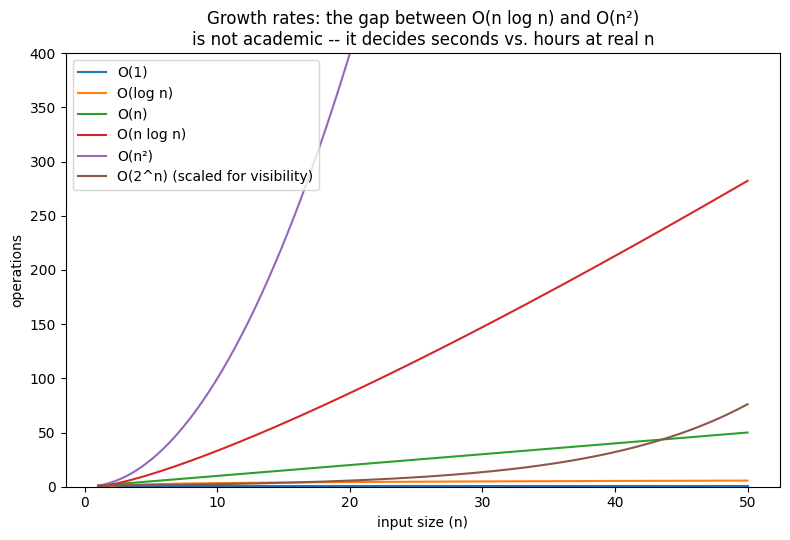

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

n = np.linspace(1, 50, 200)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(n, np.ones_like(n), label="O(1)")
ax.plot(n, np.log2(n), label="O(log n)")
ax.plot(n, n, label="O(n)")
ax.plot(n, n * np.log2(n), label="O(n log n)")
ax.plot(n, n**2, label="O(n²)")
ax.plot(n, 2**(n / 8), label="O(2^n) (scaled for visibility)")
ax.set_ylim(0, 400)
ax.set_xlabel("input size (n)")
ax.set_ylabel("operations")
ax.legend()
ax.set_title("Growth rates: the gap between O(n log n) and O(n²)\nis not academic -- it decides seconds vs. hours at real n")
fig.tight_layout()
fig.savefig(FIG_DIR / "complexity_growth.png", dpi=140)
plt.show()

At `n=1,000,000`: `O(n)` is a million operations (milliseconds), `O(n log n)` is about 20 million (still fast), `O(n²)` is a trillion (minutes to hours). This is why "can this be done better than brute force" is the single most common interview follow-up -- moving down one row of this chart is often the entire difference between a passing and failing solution.

## Deriving complexity from code: the rules

- **Sequential statements** → add. Two O(n) loops back to back is still O(n) (O(n)+O(n)=O(2n)=O(n)).
- **Nested loops** → multiply. A loop inside a loop, each O(n), is O(n²) -- regardless of whether the inner loop's bound depends on the outer variable (triangular loops are still O(n²), just with a smaller constant).
- **Loop that halves the problem each iteration** → O(log n) (binary search is the canonical example).
- **A loop calling an O(n) operation each iteration** → multiply: O(n) iterations × O(n) per iteration = O(n²). This is the single most common accidental-O(n²) bug: e.g. `x in list` (O(n)) inside a loop over that same list.

In [2]:
def has_duplicate_slow(nums):     # O(n^2): "in" on a list is O(n), called n times
    seen = []
    for x in nums:
        if x in seen:               # <- O(n) check, INSIDE an O(n) loop
            return True
        seen.append(x)
    return False

def has_duplicate_fast(nums):       # O(n): "in" on a set is O(1) average
    seen = set()
    for x in nums:
        if x in seen:                # <- O(1) average check
            return True
        seen.add(x)
    return False

import time
big = list(range(20000)) + [19999]   # duplicate at the very end -- worst case, forces a full scan

t0 = time.perf_counter(); has_duplicate_slow(big); t_slow = time.perf_counter() - t0
t0 = time.perf_counter(); has_duplicate_fast(big); t_fast = time.perf_counter() - t0
print(f"O(n^2) version: {t_slow:.4f}s")
print(f"O(n) version:   {t_fast:.4f}s")
print(f"speedup: {t_slow/t_fast:.0f}x -- from swapping a list for a set, nothing else changed")

O(n^2) version: 1.1834s
O(n) version:   0.0068s
speedup: 175x -- from swapping a list for a set, nothing else changed


## Amortized analysis: `list.append()` is O(1) amortized, not always O(1)

Python's list over-allocates capacity and doubles it when full, so most `append()` calls are a cheap write into existing space (O(1)), and occasionally one triggers an O(n) copy into a bigger array. Spread across many appends, the AVERAGE cost per append stays constant -- that averaging is what "amortized" means, and it is measurably true, not just claimed:

In [3]:
import timeit

def append_n(n):
    lst = []
    for i in range(n):
        lst.append(i)
    return lst

for n in [1000, 10000, 100000]:
    t = timeit.timeit(lambda: append_n(n), number=5)
    print(f"n={n:>7}: {t/5*1000/n:.5f} ms per append  <- roughly constant across a 100x range in n")

n=   1000: 0.00004 ms per append  <- roughly constant across a 100x range in n
n=  10000: 0.00005 ms per append  <- roughly constant across a 100x range in n
n= 100000: 0.00005 ms per append  <- roughly constant across a 100x range in n


Compare: inserting at the FRONT of a list (`insert(0, x)`) is genuinely O(n) *every* call, not amortized, because every existing element must shift -- this is exactly why `collections.deque` exists (Phase 0, notebook 02) for anything needing fast operations at both ends.

## Best / worst / average case

The SAME algorithm can have different complexities depending on the input. Quicksort is the standard example: O(n log n) average case, but O(n²) worst case on already-sorted input with a naive pivot choice (each partition only removes one element instead of roughly halving the array).

In [4]:
import sys
sys.setrecursionlimit(10000)

def quicksort_naive(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[0]                      # always picks the FIRST element -- the naive, exploitable choice
    less = [x for x in arr[1:] if x < pivot]
    more = [x for x in arr[1:] if x >= pivot]
    return quicksort_naive(less) + [pivot] + quicksort_naive(more)

import random, time

random_input = [random.randint(0, 100000) for _ in range(1500)]
sorted_input = list(range(1500))        # already sorted -- the worst case for this pivot choice

t0 = time.perf_counter(); quicksort_naive(random_input); t_avg = time.perf_counter() - t0
t0 = time.perf_counter(); quicksort_naive(sorted_input); t_worst = time.perf_counter() - t0
print(f"random input (average case):  {t_avg:.4f}s")
print(f"sorted input (worst case):    {t_worst:.4f}s  <- same size, same algorithm, much slower")

random input (average case):  0.0019s
sorted input (worst case):    0.0778s  <- same size, same algorithm, much slower


In interviews, "what's the complexity" almost always means worst case unless stated otherwise -- but being able to name the average and best cases too, and *why* they differ, is what separates a memorized answer from real understanding.

## Space complexity: do not forget the call stack

Space complexity counts auxiliary space (extra memory used, not counting the input itself) -- including the recursion call stack, which is easy to forget. A recursive function with no explicit data structures can still be O(n) space, purely from stack depth.

In [5]:
def sum_recursive(nums):          # O(n) time, and O(n) SPACE -- one stack frame per element
    if not nums:
        return 0
    return nums[0] + sum_recursive(nums[1:])

def sum_iterative(nums):          # O(n) time, O(1) SPACE -- no growing call stack
    total = 0
    for x in nums:
        total += x
    return total

nums = list(range(1000))
print(sum_recursive(nums) == sum_iterative(nums) == sum(nums))
print("recursive version: O(n) time AND O(n) space (1000 stack frames)")
print("iterative version: O(n) time, O(1) space")

True
recursive version: O(n) time AND O(n) space (1000 stack frames)
iterative version: O(n) time, O(1) space


## Practice: name the complexity

For each function below, state time and space complexity before running the check cell.

In [6]:
def mystery_a(n):
    count = 0
    for i in range(n):
        for j in range(i, n):        # bound depends on i -- still O(n^2), just triangular
            count += 1
    return count

def mystery_b(n):
    i = 1
    count = 0
    while i < n:
        i *= 2                        # doubles each time -> O(log n) iterations
        count += 1
    return count

def mystery_c(nums):
    return sorted(nums)[:3]           # dominated by the sort: O(n log n)

print("mystery_a(5) =", mystery_a(5), " -- what's the time complexity in terms of n?")
print("mystery_b(64) =", mystery_b(64), " -- what's the time complexity in terms of n?")
print("mystery_c([5,3,8,1,9,2]) =", mystery_c([5, 3, 8, 1, 9, 2]), " -- what's the time complexity in terms of n?")

mystery_a(5) = 15  -- what's the time complexity in terms of n?
mystery_b(64) = 6  -- what's the time complexity in terms of n?
mystery_c([5,3,8,1,9,2]) = [1, 2, 3]  -- what's the time complexity in terms of n?


**Answers:** `mystery_a`: O(n²) time (a triangular double loop is still quadratic, just with a smaller constant than a full n×n), O(1) space. `mystery_b`: O(log n) time (halving/doubling pattern), O(1) space. `mystery_c`: O(n log n) time (the sort dominates the O(n) slice), O(n) space (a new sorted list is created).

## Self-check before moving on

- [ ] I can derive Big-O from code by reading it, without running it, for loops, nested loops, and halving patterns
- [ ] I can explain why `list.append()` is amortized O(1) and why `list.insert(0, x)` is not
- [ ] I can name a real algorithm whose best/worst/average case differ, and explain why
- [ ] I remember to count recursion call-stack depth as space, not just explicit data structures
- [ ] Given unfamiliar code, I can state time AND space complexity within about a minute

Next: `02-python-dsa-toolkit-refresher.ipynb`